In [1]:
# Install (already available in Colab, just import)
import pandas as pd          # for data handling
import numpy as np           # for math operations
import matplotlib.pyplot as plt  # for graphs
import seaborn as sns        # for beautiful graphs
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load your dataset
df = pd.read_csv("/content/archive (1).zip")

# Explore it
print(df.head())         # first 5 rows
print(df.shape)          # rows and columns
print(df.describe())     # statistics
print(df.isnull().sum()) # check for missing values

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

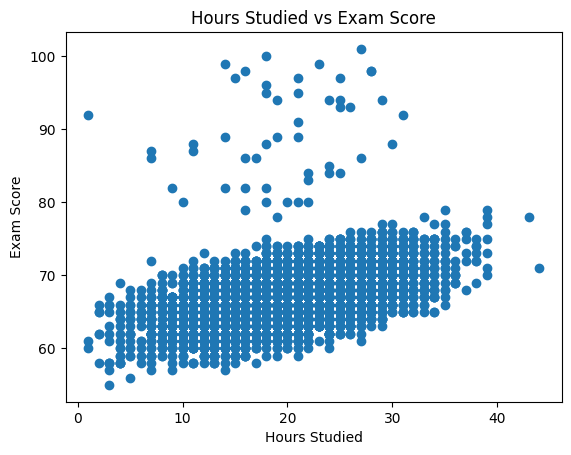

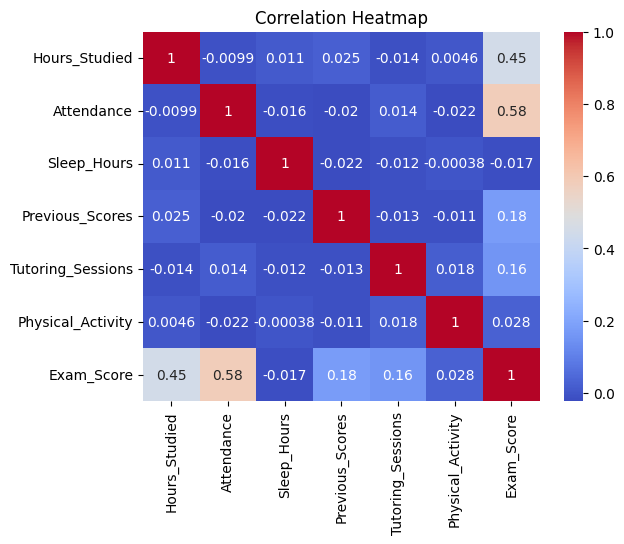

In [5]:
# See how study hours relate to scores
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.show()

# Heatmap to see all relationships
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
# Select your input features (X) and target (y)
X = df[['Hours_Studied', 'Sleep_Hours', 'Attendance']]
y = df['Exam_Score']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 5285
Testing samples: 1322


In [8]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# See what the model learned
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 0.2891957  -0.04740738  0.19827206]
Intercept: 45.937048965691304


In [9]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")  # Closer to 1.0 = better model

Mean Squared Error: 5.82
R² Score: 0.59


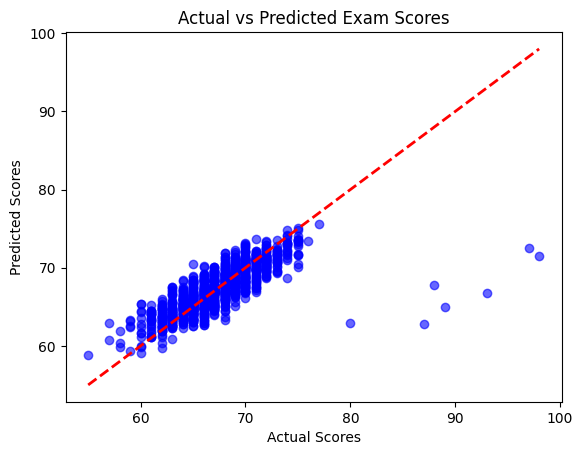

In [10]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Exam Scores')
plt.show()